<h1 style="text-align:center; font-size:42px; margin-top:40px;">

Traitement des valeurs manquantes & gestion des outliers

</h1>

## 1. Contexte et objectif

Ce module intervient après la suppression des doublons.  
L’objectif est de produire une version **stabilisée**, débarrassée des incohérences majeures et prête pour les étapes de normalisation.

Plus précisément, ce notebook vise à :

- analyser la structure des valeurs manquantes ;
- imputer les colonnes catégorielles essentielles ;
- corriger et nettoyer les valeurs extrêmes (outliers) dans les variables salariales ;
- reconstruire une partie des salaires annuels manquants (`ConvertedCompYearly`) via les taux de change ;
- finaliser l’imputation par pays, puis par médiane lorsque nécessaire.

Le dataset obtenu servira directement au module suivant : **normalisation & traitement des incohérences**.


## 2. Librairies et chargement des données

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("../Data/Survey/processed/survey-data_V1_noduplicates.csv")
df.head()

,ResponseId,MainBranch,Age,RemoteWork,Employment,Country,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,SOAccount,SOPartFreq,AISelect,AIBen,AIChallenges,JobSat,Industry,OpSysProfessional use,NEWCollabToolsHaveWorkedWith,AIToolCurrently Using
0,1,I am a developer by profession,Under 18 years old,Remote,"Employed, full-time",United States of America,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,Yes,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,Remote,"Employed, full-time",United Kingdom of Great Britain and Northern I...,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,Yes,Multiple times per day,"No, and I don't plan to",NaN,NaN,NaN,NaN,MacOS,PyCharm;Visual Studio Code;WebStorm,NaN
2,3,I am a developer by profession,45-54 years old,Remote,"Employed, full-time",United Kingdom of Great Britain and Northern I...,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,Yes,Multiple times per day,"No, and I don't plan to",NaN,NaN,NaN,NaN,Windows,Visual Studio,NaN
3,4,I am learning to code,18-24 years old,NaN,"Student, full-time",Canada,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,No,NaN,Yes,Increase productivity;Greater efficiency;Impro...,Don’t trust the output or answers,NaN,NaN,NaN,NaN,Learning about a codebase;Project planning;Wri...
4,5,I am a developer by profession,18-24 years old,NaN,"Student, full-time",Norway,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,Yes,Multiple times per day,"No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,Vim,NaN


## 3. Identification des valeurs manquantes

Avant toute imputation, une analyse globale des valeurs manquantes est réalisée.  
L’objectif est d’identifier les colonnes critiques et d’adapter le type d’imputation en fonction de :

- la nature de la variable (catégorielle / numérique) ;
- sa distribution ;
- son importance dans les analyses à venir ;
- le risque de biais introduit par l'imputation.


In [3]:
# Compter les valeurs manquantes par colonne
missing_values = df.isnull().sum()

# Résumer les résultats
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.count(),
    "Missing Values": missing_values
}).sort_values(by="Missing Values",ascending=False)

print(summary)

                             Data Type  Non-Null Count  Missing Values
EmbeddedAdmired                 object           16139           45062
EmbeddedWantToWorkWith          object           16970           44231
EmbeddedHaveWorkedWith          object           21393           39808
ConvertedCompYearly            float64           23423           37778
Industry                        object           28819           32382
MiscTechAdmired                 object           28833           32368
JobSat                         float64           29086           32115
PlatformAdmired                 object           30614           30587
MiscTechWantToWorkWith          object           32113           29088
PlatformWantToWorkWith          object           33649           27552
CompTotal                      float64           33722           27479
AIToolCurrently Using           object           33825           27376
WebframeAdmired                 object           34024           27177
AIBen 

#### Heatmap des valeurs manquantes

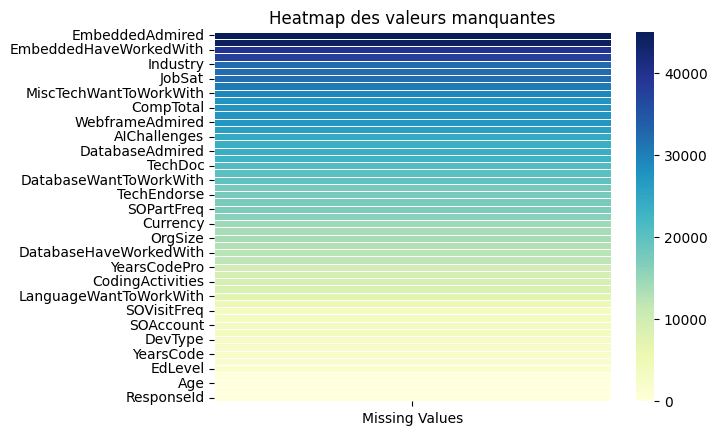

In [4]:
sns.heatmap(summary[["Missing Values"]],cmap="YlGnBu",cbar=True,linewidths=0.5, linecolor="white")
plt.title("Heatmap des valeurs manquantes")
plt.show()

## 4. Imputation des colonnes catégorielles

### 4.1 RemoteWork (catégorielle)

In [5]:
#affichage des valeurs unique de la colonne RemoteWork
print("Nombre de valeurs manquantes", df["RemoteWork"].isna().sum())
df["RemoteWork"].value_counts()

Nombre de valeurs manquantes 8742


RemoteWork
Hybrid (some remote, some in-person)    21988
Remote                                  20168
In-person                               10303
Name: count, dtype: int64

Variable catégorielle simple.  
L’imputation se fait par le **mode**, car la distribution est claire et non biaisée.

In [6]:
mode=df["RemoteWork"].value_counts().idxmax()
print("la valeur la plus frequente est : ",mode)
df["RemoteWork"]=df["RemoteWork"].fillna(mode)
print("nombre de valeur manquantes apres emputation ",df["RemoteWork"].isna().sum() )

la valeur la plus frequente est :  Hybrid (some remote, some in-person)
nombre de valeur manquantes apres emputation  0


### 4.2 EdLevel (catégorielle)

In [7]:
#affichage des valeurs unique de la colonne EdLevel
df["EdLevel"].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          24605
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       15497
Some college/university study without earning a degree                                 7526
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     5247
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2965
Associate degree (A.A., A.S., etc.)                                                    1792
Primary/elementary school                                                              1017
Something else                                                                          925
Name: count, dtype: int64

Même logique : imputation par le **mode**, car la valeur la plus fréquente représente bien la majorité.

In [8]:
print("nombre de valeurs manquantes:",df["EdLevel"].isna().sum())
print("type colonne",df["EdLevel"].dtype)
mode=df["EdLevel"].value_counts().idxmax()
print("valeur frequente :",mode)
df["EdLevel"]=df["EdLevel"].fillna(mode)
print("nombre de valeurs manquantes aprés imputation :",df["EdLevel"].isna().sum())

nombre de valeurs manquantes: 1627
type colonne object
valeur frequente : Bachelor’s degree (B.A., B.S., B.Eng., etc.)
nombre de valeurs manquantes aprés imputation : 0


### 4.3 Industry (catégorielle)

In [9]:
#affichage des valeurs unique de la colonne EdLevel
print("nombre de valeurs manquantes :",df["Industry"].isna().sum())
df["Industry"].value_counts()

nombre de valeurs manquantes : 32382


Industry
Software Development                          11902
Other:                                         3076
Fintech                                        1637
Internet, Telecomm or Information Services     1626
Banking/Financial Services                     1370
Healthcare                                     1273
Retail and Consumer Services                   1263
Manufacturing                                  1262
Government                                      959
Media & Advertising Services                    893
Higher Education                                890
Transportation, or Supply Chain                 859
Computer Systems Design and Services            844
Energy                                          577
Insurance                                       388
Name: count, dtype: int64

Cette variable présente près de 50 % de valeurs manquantes.  
L’imputation par le mode créerait un biais important en surreprésentant artificiellement une seule industrie.

L’imputation est réalisée avec la catégorie `"Unknown"`.  

In [10]:
df["Industry"]=df["Industry"].fillna("Unknown")
print("number of missing value affter imputing missing values :",df["Industry"].isna().sum())

number of missing value affter imputing missing values : 0


## 5. Imputation des colonnes numériques

### 5.1 JobSat (numérique)

In [11]:
print("Nombre de valeurs manquantes :",df["JobSat"].isna().sum())

Nombre de valeurs manquantes : 32115


Examinant la distribution

Text(0.5, 1.0, 'Distribution de la colonne JobSat')

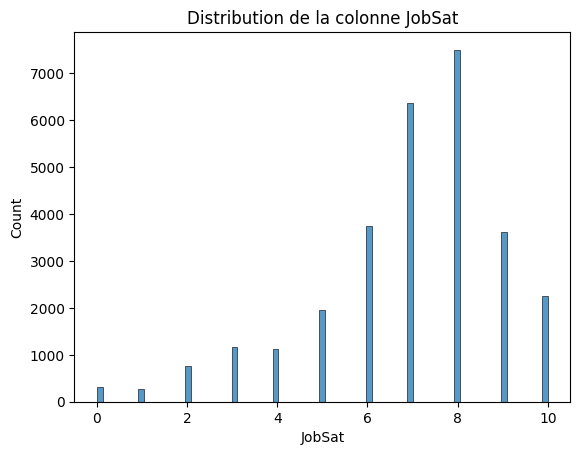

In [12]:
sns.histplot(df["JobSat"])
plt.title("Distribution de la colonne JobSat")

La distribution étant asymétrique, l’imputation est réalisée via la **médiane**, plus robuste que la moyenne.

In [13]:
# On impute par la median car la distribution n'est pas symétrique 
df["JobSat"]=df["JobSat"].fillna(df["JobSat"].median())
print("nombre de valeurs manquantes apres imputation:",df["JobSat"].isna().sum())

nombre de valeurs manquantes apres imputation: 0


### 5.2 YearsCodePro (numérique + valeurs textuelles à normaliser)

In [14]:
df["YearsCodePro"].value_counts()

YearsCodePro
2                     4154
3                     4076
5                     3518
10                    3246
4                     3207
6                     2839
Less than 1 year      2767
1                     2623
8                     2545
7                     2510
12                    1775
15                    1635
20                    1549
9                     1492
11                    1311
13                    1126
14                    1082
25                     996
16                     946
18                     867
17                     814
30                     687
24                     632
19                     516
22                     492
23                     448
26                     426
21                     380
27                     380
28                     342
35                     285
29                     196
40                     194
32                     194
34                     169
38                     134
33             

Deux valeurs textuelles doivent etre converties avant de changer le type en float :
- `"Less than 1 year"` → 0.5  
- `"More than 50 years"` → 51  

In [15]:
# changement de type vers numérique
df["YearsCodePro"]=df["YearsCodePro"].replace('Less than 1 year',0.5)
df["YearsCodePro"]=df["YearsCodePro"].replace('More than 50 years',51)

df["YearsCodePro"]=df["YearsCodePro"].astype(float)

Analysant la distribution de la colonne YearsCodePro

Text(0.5, 1.0, 'Distribution de la variable YearsCodePro')

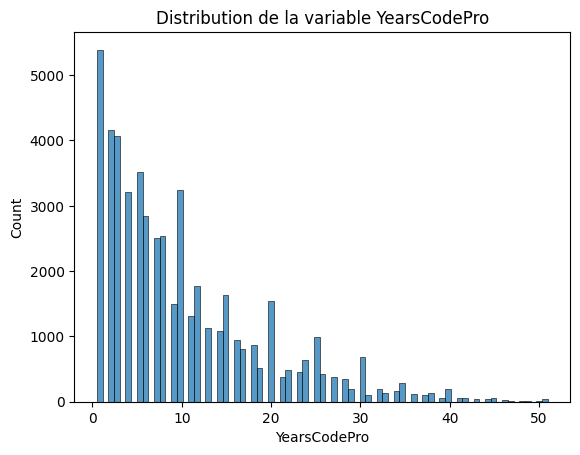

In [16]:
sns.histplot(df["YearsCodePro"])
plt.title("Distribution de la variable YearsCodePro")

La distribution n’étant pas normale → imputation via **médiane**.

In [17]:
print("nombre de valeurs manquante :",df["YearsCodePro"].isna().sum())
median=df["YearsCodePro"].median()
print("mediane :",median)
df["YearsCodePro"]=df["YearsCodePro"].fillna(median)
print("nombre de valeurs manquantes aprés imputation:",df["YearsCodePro"].isna().sum())

nombre de valeurs manquante : 9773
mediane : 8.0
nombre de valeurs manquantes aprés imputation: 0


## 6. Traitement des données salariales

Les colonnes `CompTotal` et `ConvertedCompYearly` sont essentielles mais contiennent :

- des valeurs aberrantes fortes ;
- des incohérences entre devises ;
- des valeurs manquantes nombreuses.

La méthodologie appliquée :

1. **Analyse exploratoire** : relation entre `CompTotal` et `ConvertedCompYearly` par devise.
2. **Détection des outliers via IQR** : remplacement des points extrêmes par `NaN`.
3. **Estimation des taux de change** : moyenne `CompTotal / ConvertedCompYearly` pour chaque devise.
4. **Reconstruction partielle** de `ConvertedCompYearly` selon :
   - calcul direct via taux de change ;
   - imputation par **moyenne par pays** si possible ;
   - imputation finale via **médiane globale** si information insuffisante.

Cette approche garantit une reconstruction cohérente et évite de propager des erreurs dues aux outliers.


In [18]:
# Extraction des données salariales 
df_renum=df[df["CompTotal"].notna()][["Country","Currency","CompTotal","ConvertedCompYearly"]]
df_renum

,Country,Currency,CompTotal,ConvertedCompYearly
72,Pakistan,PKR\tPakistani rupee,2040000.0,7322.0
374,Austria,EUR European Euro,28000.0,30074.0
379,Turkey,EUR European Euro,85000.0,91295.0
385,France,EUR European Euro,50000.0,53703.0
389,United States of America,USD\tUnited States dollar,110000.0,110000.0
...,...,...,...,...
61177,Lithuania,EUR European Euro,36000.0,NaN
61180,France,EUR European Euro,40000.0,NaN
61185,France,EUR European Euro,61000.0,NaN
61188,Italy,EUR European Euro,58000.0,NaN


### 6.1 Observation exploratoire : Currency vs CompTotal vs ConvertedCompYearly

Avant de traiter ConvertedCompYearly, il faut comprendre si cette colonne correspond vraiment à un salaire converti en USD ou non.

#### A. Étude des corrélations visuelles par devise (Currency) :

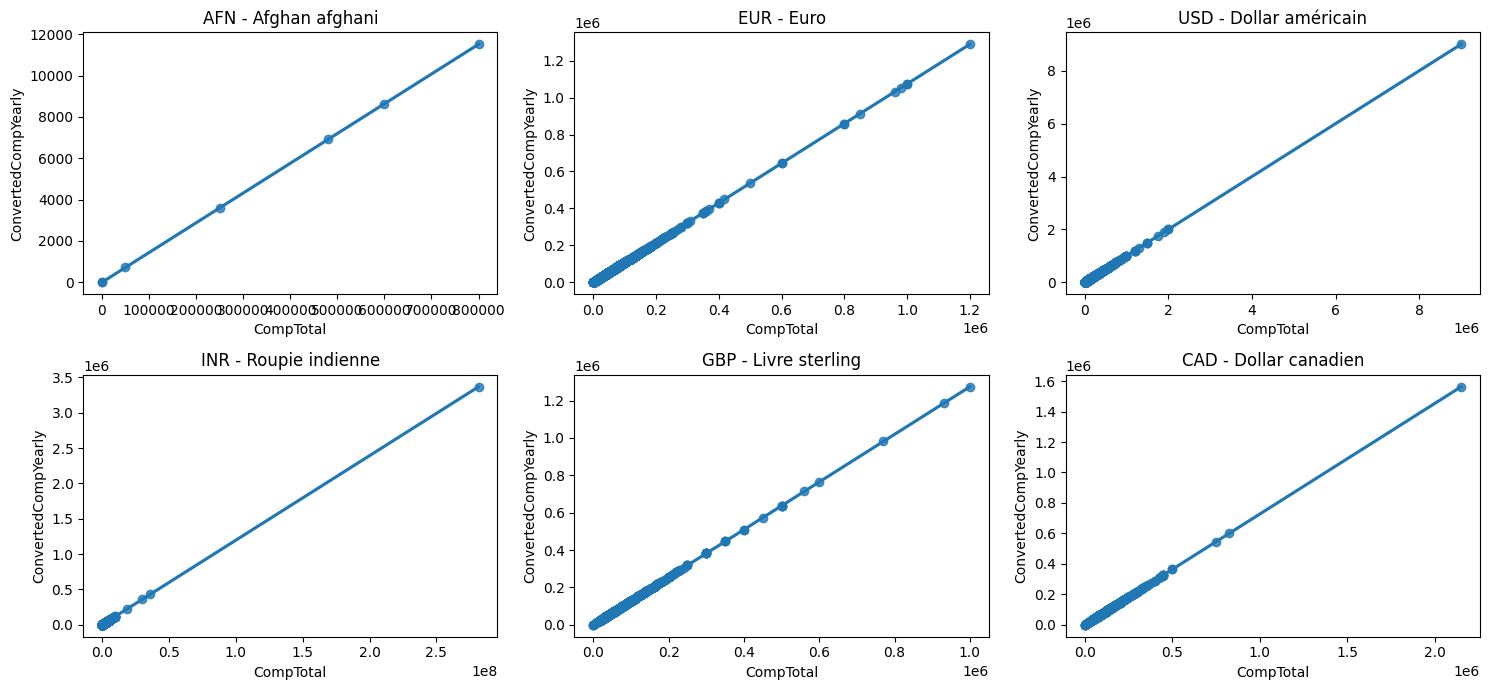

In [19]:
fig,ax = plt.subplots(2,3,figsize=(15,7))

sns.regplot(data=df[df["Currency"]=="AFN\tAfghan afghani"], x="CompTotal", y="ConvertedCompYearly", ax=ax[0,0])
ax[0,0].set_title("AFN - Afghan afghani")

sns.regplot(data=df[df["Currency"]=="EUR European Euro"], x="CompTotal", y="ConvertedCompYearly", ax=ax[0,1])
ax[0,1].set_title("EUR - Euro")

sns.regplot(data=df[df["Currency"]=="USD\tUnited States dollar"], x="CompTotal", y="ConvertedCompYearly", ax=ax[0,2])
ax[0,2].set_title("USD - Dollar américain")

sns.regplot(data=df[df["Currency"]=="INR\tIndian rupee"], x="CompTotal", y="ConvertedCompYearly", ax=ax[1,0])
ax[1,0].set_title("INR - Roupie indienne")

sns.regplot(data=df[df["Currency"]=="GBP\tPound sterling"], x="CompTotal", y="ConvertedCompYearly", ax=ax[1,1])
ax[1,1].set_title("GBP - Livre sterling")

sns.regplot(data=df[df["Currency"]=="CAD\tCanadian dollar"], x="CompTotal", y="ConvertedCompYearly", ax=ax[1,2])
ax[1,2].set_title("CAD - Dollar canadien")

plt.tight_layout()
plt.show()


#### b. Conclusion exploratoire

On observe une relation linéaire forte entre CompTotal et ConvertedCompYearly, peu importe la devise.
Cela suggère que ConvertedCompYearly est une version convertie du salaire annuel en USD (ou un équivalent standard), avec une conversion fixe par devise.
Cette hypothèse va être exploitée pour reconstruire les valeurs manquantes.

### 6.2  Observation de la distribution des colonnes CompTotal et ConvertedCompYearly

Text(0.5, 1.0, 'Distribution de la colonne ConvertedCompYearly')

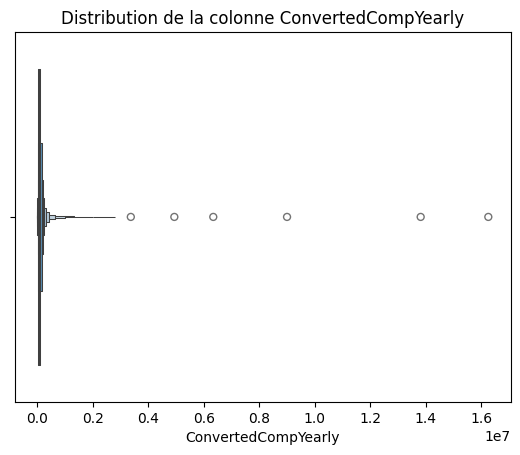

In [20]:
sns.boxenplot(x=df_renum["ConvertedCompYearly"])
plt.title("Distribution de la colonne ConvertedCompYearly")

Text(0.5, 1.0, 'Distribution de la colonne CompTotal')

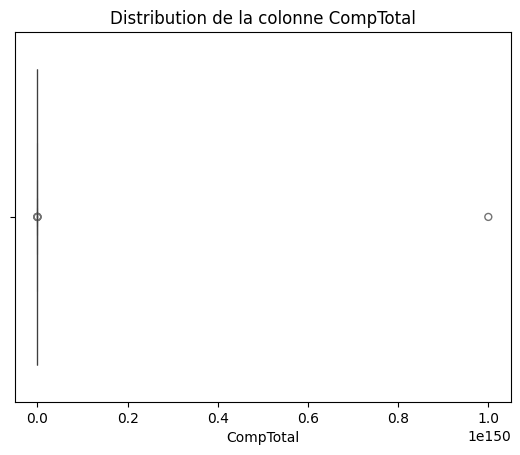

In [21]:
sns.boxenplot(x=df_renum["CompTotal"])
plt.title("Distribution de la colonne CompTotal")

On remarque beaucoup de valeurs abberantes , on va les remplacer par nan pour les traiter plustard avec les valeurs manquantes

### 6.3 Suppression des valeurs aberrantes (outliers) via IQR

In [22]:
for col in ["CompTotal", "ConvertedCompYearly"]:
    Q1, Q3 = df[col].quantile([0.25,0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    # on remplace les valeurs aberrantes par NAN
    df[col] = df[col].where(df[col].between(lower,upper), pd.NA)


### 6.4 Reconstruction de ConvertedCompYearly

#### A. Calcul de taux de change par devise (basé sur les lignes valides)

In [23]:
#nous ajoutons une nouvelle colonne contient le taux de change utilisé en faisant CompTotal/ConvertedCompYearly
df["taux_change"]=round(df["CompTotal"]/df["ConvertedCompYearly"],2)
df[df["taux_change"].notna()][["Currency","taux_change"]].sort_values(by="taux_change")

,Currency,taux_change
7180,KWD\tKuwaiti dinar,0.31
16033,KWD\tKuwaiti dinar,0.31
1239,BHD\tBahraini dinar,0.38
18067,BHD\tBahraini dinar,0.38
26414,BHD\tBahraini dinar,0.38
...,...,...
38836,IDR\tIndonesian rupiah,16129.03
34056,IDR\tIndonesian rupiah,17500.00
37829,VND\tVietnamese dong,25000.00
5060,SLL\tSierra Leonean leone,30000.00


Le taux de change peut varier selon le temps, nous calculons la moyenne des taux de change par currency 

In [24]:
taux_change=df.groupby("Currency")["taux_change"].mean().round(2).to_frame().reset_index()
taux_change.columns=["Currency","taux_calc"]
taux_change

,Currency,taux_calc
0,AED United Arab Emirates dirham,3.67
1,AFN\tAfghan afghani,64.99
2,ALL\tAlbanian lek,93.11
3,AMD\tArmenian dram,390.79
4,ANG Netherlands Antillean guilder,2.00
...,...,...
137,YER\tYemeni rial,250.47
138,ZAR\tSouth African rand,18.58
139,ZMW Zambian kwacha,26.31
140,none\tCook Islands dollar,NaN


Nous faisons une jointure entre df et la dataframe des taux de change pour inserer la colonne taux_calc dans df

In [25]:
df=pd.merge(df,taux_change,on="Currency",how="left")

In [26]:
#Supprimer la colonne taux_change initial 
df=df.drop(columns=["taux_change"])

#### B. Imputation : ConvertedCompYearly = CompTotal / taux_calc

In [27]:
print("nombre de valeurs manquante avant le transformation",df["ConvertedCompYearly"].isna().sum())

# imputation des valeurs manquantes selon la condition ConvertedCompYearly nul, et comptTotal et taux_calc non null
mask = df["ConvertedCompYearly"].isna() & df["CompTotal"].notna() & df["taux_calc"].notna()
df.loc[mask, "ConvertedCompYearly"] = df.loc[mask, "CompTotal"] / df.loc[mask, "taux_calc"]

print("nombre de valeurs manquante aprés la transformation",df["ConvertedCompYearly"].isna().sum())


nombre de valeurs manquante avant le transformation 38756
nombre de valeurs manquante aprés la transformation 29365


#### C. Imputation par moyenne par Country (valeurs non calculable) 

In [28]:
mean_by_country = df.groupby("Country")["ConvertedCompYearly"].transform("mean")

# 2) Imputer les valeurs manquantes avec la moyenne de leur pays
mask_nan = df["ConvertedCompYearly"].isna()
df.loc[mask_nan, "ConvertedCompYearly"] = mean_by_country[mask_nan]

print("nombre de valeurs manquante aprés la transformation",df["ConvertedCompYearly"].isna().sum())

nombre de valeurs manquante aprés la transformation 3382


#### Observant le reste des valeurs manquantes de la colonne ContertedComYearly

In [29]:
df[df["ConvertedCompYearly"].isna()][["Country","Currency","CompTotal","ConvertedCompYearly","taux_calc"]]

,Country,Currency,CompTotal,ConvertedCompYearly,taux_calc
276,San Marino,NaN,NaN,NaN,NaN
2185,Gabon,USD\tUnited States dollar,NaN,NaN,1.0
2229,Bahamas,NaN,NaN,NaN,NaN
4330,Swaziland,NaN,NaN,NaN,NaN
5429,North Korea,NaN,NaN,NaN,NaN
...,...,...,...,...,...
61193,NaN,NaN,NaN,NaN,NaN
61194,NaN,NaN,NaN,NaN,NaN
61196,NaN,NaN,NaN,NaN,NaN
61198,NaN,NaN,NaN,NaN,NaN


Nous ne disposons pas assez d'information pour calculer ConvertedCompYearly, on va visualiser la distribution de la variable ConvertedCompYearly pour voir diterminer qui correspond mieux la moyenne ou la medianne

Text(0.5, 1.0, 'Distribution de la colonne ConvertedCompYearly')

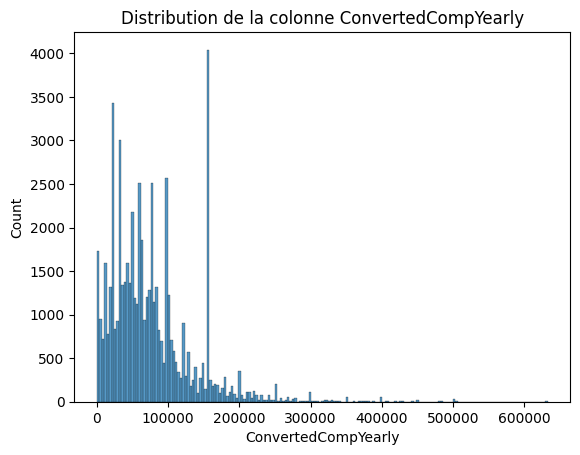

In [30]:
sns.histplot(df["ConvertedCompYearly"])
plt.title("Distribution de la colonne ConvertedCompYearly")

En observant la distribution des salaires annuels (ConvertedCompYearly), on constate une forte asymétrie à droite (distribution non normale), avec des valeurs extrêmes élevées.
Cette configuration rend la moyenne peu représentative du centre réel des données.
C’est pourquoi j’ai choisi d’utiliser la médiane comme méthode d’imputation des valeurs manquantes, car elle est robuste aux outliers et reflète mieux la tendance centrale dans ce contexte.

#### C. Imputation par mediane générale

In [31]:
df["ConvertedCompYearly"]=df["ConvertedCompYearly"].fillna(df["ConvertedCompYearly"].median())
print("le nombre de valeurs manquante apres imputation avec salaire moyen general ",df["ConvertedCompYearly"].isna().sum())

le nombre de valeurs manquante apres imputation avec salaire moyen general  0


## 7. Suppression des colonnes intermédiaires

In [32]:
# supprimer les colonne CompTotal et taux_calc
df = df.drop(columns=["CompTotal", "taux_calc"])

## 8. Export du dataset nettoyé

In [33]:
df.to_csv("../Data/Survey/processed/survey-data_V2_clean_missing_outliers.csv", index=False)

## 9. Résumé

Ce module a permis de stabiliser le dataset après déduplication.  
Les principales actions réalisées :

- imputation ciblée des variables catégorielles essentielles ;
- correction des distributions numériques asymétriques ;
- traitement des valeurs aberrantes des salaires ;
- reconstruction cohérente d’une partie de `ConvertedCompYearly` via taux de change ;
- imputation finale par pays puis par médiane.

Le dataset **V2** est désormais propre, cohérent, et prêt pour l’étape suivante :  
**normalisation & gestion des valeurs inconsistantes**.
